In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import joblib

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

model = joblib.load('../models/fraud_model_tuned.joblib')

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("Data and model loaded!")

Data and model loaded!


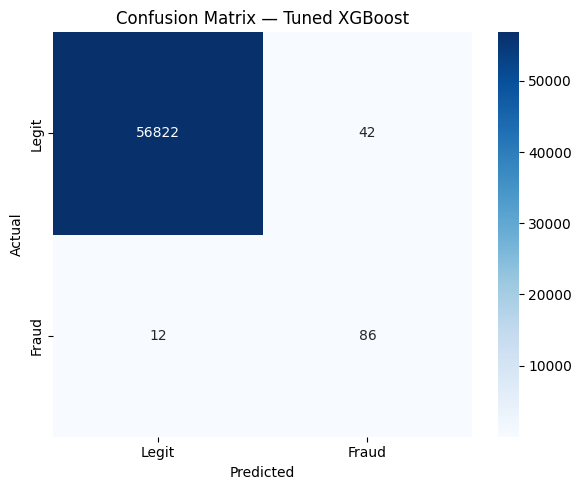

True Positives (caught fraud): 86
False Positives (false alarms): 42
False Negatives (missed fraud): 12
True Negatives (correct legit): 56822


In [3]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (caught fraud): {tp}")
print(f"False Positives (false alarms): {fp}")
print(f"False Negatives (missed fraud): {fn}")
print(f"True Negatives (correct legit): {tn}")

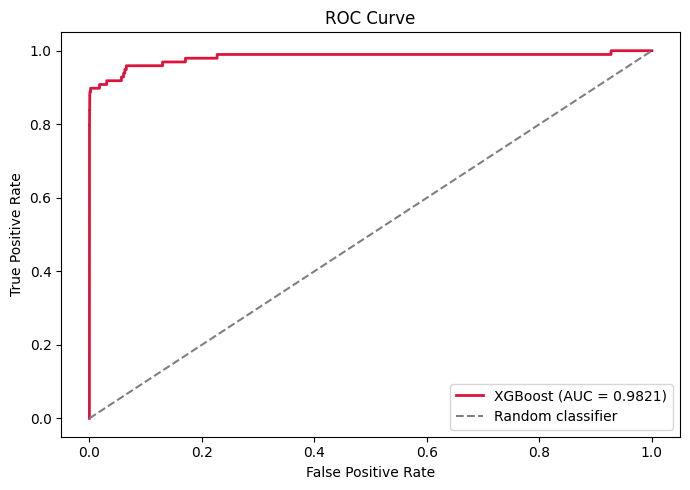

In [4]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png')
plt.show()

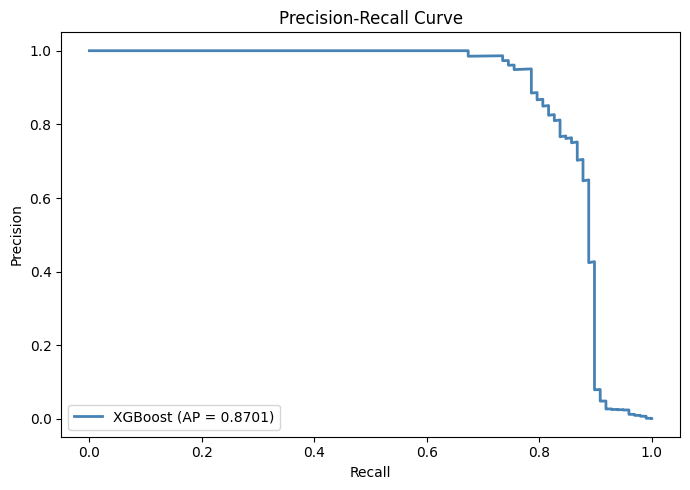

In [5]:
precision, recall, _ = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'XGBoost (AP = {ap:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/precision_recall_curve.png')
plt.show()